# House Prices:

## 1. Import thư viện

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import wandb

print("PyTorch:", torch.__version__)

PyTorch: 2.11.0+cpu


## 2. Load Data

In [4]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Kích thước tập Train: ", train.shape)
print("Kích thước tập Test: ", test.shape)

Kích thước tập Train:  (1460, 81)
Kích thước tập Test:  (1459, 80)


- **Tập Train:** Có **1.460** dòng tương đương với **1.460 căn nhà** và **81 cột** (trong đó bao gồm **80 cột đặc trưng của nhà** và **1 cột nhãn `SalePrice`**)

- **Tập Test:** Có **1.459** dòng tương đương với **1.459 căn nhà** và **80 cột** (đã bỏ cột nhãn `SalePrice`)

In [5]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Data Analysis

In [6]:
pd.set_option("display.max_rows", 100)

cols_df = pd.DataFrame(
    {
        "STT": range(1, len(train.columns) + 1),
        "Tên Cột (Column)": train.columns,
        "Kiểu Dữ Liệu (Dtype)": train.dtypes.values,
        "Số Ô Có Dữ Liệu": train.notnull().sum().values,
        "Số Ô Bị Thiếu (NaN)": train.isnull().sum().values,
    }
)

cols_df

,STT,Tên Cột (Column),Kiểu Dữ Liệu (Dtype),Số Ô Có Dữ Liệu,Số Ô Bị Thiếu (NaN)
0,1,Id,int64,1460,0
1,2,MSSubClass,int64,1460,0
2,3,MSZoning,object,1460,0
3,4,LotFrontage,float64,1201,259
4,5,LotArea,int64,1460,0
5,6,Street,object,1460,0
6,7,Alley,object,91,1369
7,8,LotShape,object,1460,0
8,9,LandContour,object,1460,0
9,10,Utilities,object,1460,0


In [7]:
print("Thống kê mô tả")
print(train.describe())

Thống kê mô tả
                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1201.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    70.049958   10516.828082     6.099315   
std     421.610009    42.300571    24.284752    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    59.000000    7553.500000     5.000000   
50%     730.500000    50.000000    69.000000    9478.500000     6.000000   
75%    1095.250000    70.000000    80.000000   11601.500000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  ...  \
count  1460.000000  1460.000000   1460.000000  1452.000000  1460.000000  ...   
mean      5.575342  1971.267808   1984.865753   103.685262   443.639726  ...   
std       1.112799    30.202904     20.645407   181.066207  

**1. Tổng quan về biến mục tiêu (`SalePrice`):**
- Giá trung bình (Mean): ~$180,921 với độ lệch chuẩn khá lớn (std ~$79,442).

- Khoảng giá (Min - Max): Căn thấp nhất là $34,900 và căn đắt nhất lên tới $755,000.

- Độ lệch (Skewness): Trung vị (Median - 50%) là $163,000, nhỏ hơn đáng kể so với Giá trung bình ($180,921). Điều này khẳng định giá nhà bị lệch phải rất mạnh (Right-skewed)

**2. Đặc điểm phân bố các đặc trưng (Features Distribution):**
- Các biến diện tích (LotArea, GrLivArea, BsmtFinSF1...): Có khoảng biến thiên cực kỳ rộng và chứa nhiều giá trị ngoại lệ (Outliers). Ví dụ: LotArea nhỏ nhất là 1,300 $\text{ft}^2$ nhưng lớn nhất lên tới 215,245 $\text{ft}^2$

- OverallQual (Chất lượng tổng thể): Đánh giá từ 1 đến 10, trung bình là 6.09 (mức khá/tốt).

**3. Tình trạng dữ liệu khuyết (Missing Values):**
- Nhiều cột có đủ 1460 non-null (không thiếu).

- Một số cột thiếu khá nặng, ví dụ như LotFrontage (chỉ có 1201/1460 giá trị) hay Alley (chỉ có 91/1460 giá trị, tức thiếu hơn 93%)

### Phân phối của biến mục tiêu

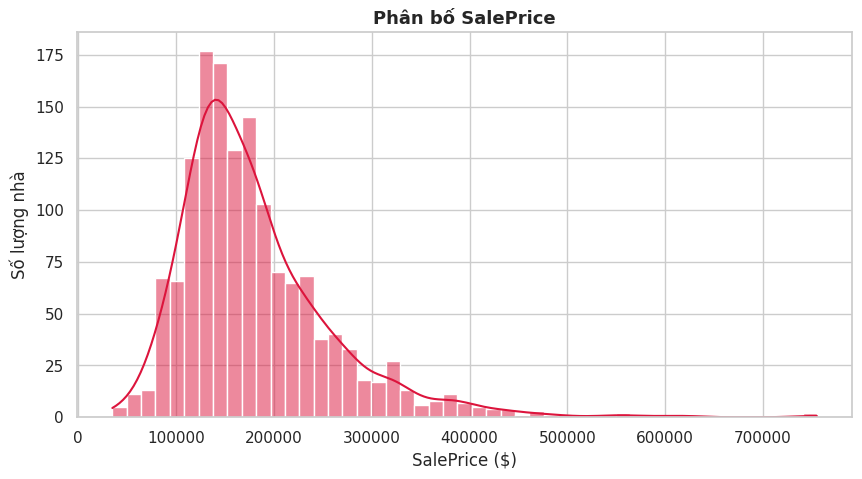

In [8]:

# Phân phối SalePrice ban đầu
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

sns.histplot(train["SalePrice"], kde=True, color="crimson")
plt.title("Phân bố SalePrice", fontsize=13, fontweight="bold")
plt.xlabel("SalePrice ($)")
plt.ylabel("Số lượng nhà")

plt.show()

- Biểu đồ bị **lệch phải** rất mạnh (Right-skewed). Phần lớn giá nhà tập trung từ **$100,000 đến $200,000**, nhưng có đuôi dài kéo về **bên phải** với những căn đắt vượt trội ($500,000 - $750,000).

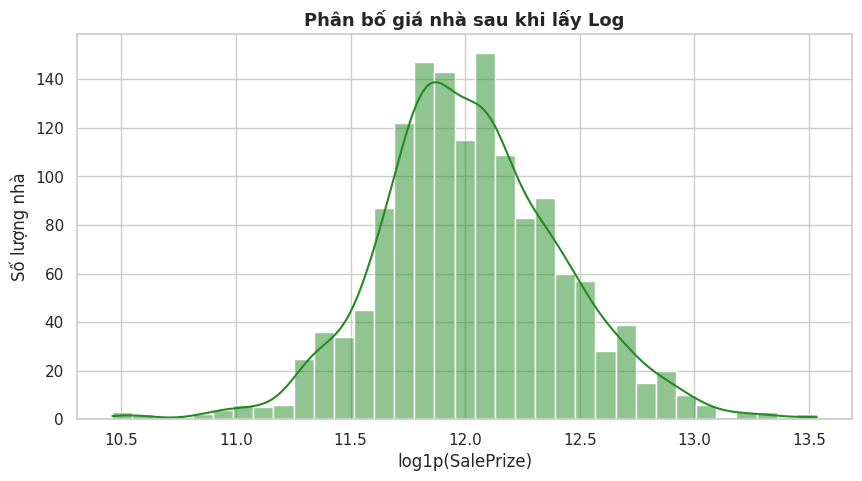

In [9]:
# Phân bố giá nhà sau khi lấy Log (log1p)
plt.figure(figsize=(10, 5))

log_saleprice = np.log1p(train["SalePrice"])
sns.histplot(log_saleprice, kde=True, color='forestgreen')

plt.title("Phân bố giá nhà sau khi lấy Log", fontsize=13, fontweight="bold")
plt.xlabel("log1p(SalePrize)")
plt.ylabel("Số lượng nhà")

plt.show()

- Sau khi biến đổi bằng `np.log1p()`, biểu đồ đã chuyển về **phân bố chuẩn** (hình chuông cân đối). Điều này giúp mô hình Neural Network không bị ảnh hưởng tiêu cực bởi các điểm dị biệt (outliers)

### Top 10 đặc trưng thiếu dữ liệu nhiều nhất

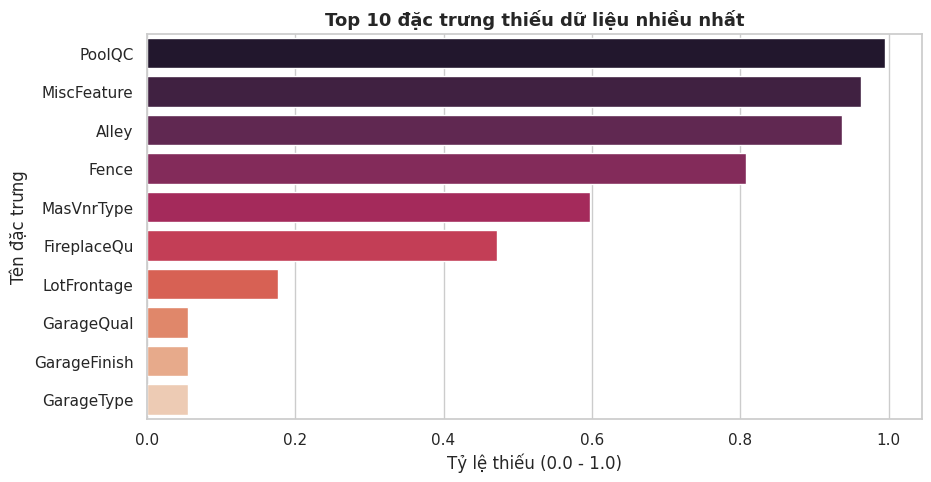

In [10]:

plt.figure(figsize=(10, 5))

missing_ratio = (train.isnull().sum() / len(train)).sort_values(ascending=False)
top_missing = missing_ratio[missing_ratio > 0].head(10)

sns.barplot(
    x=top_missing.values,
    y=top_missing.index,
    palette="rocket",
    hue=top_missing.index,
    legend=False,
)

plt.title("Top 10 đặc trưng thiếu dữ liệu nhiều nhất", fontsize=13, fontweight="bold")
plt.xlabel("Tỷ lệ thiếu (0.0 - 1.0)")
plt.ylabel("Tên đặc trưng")

plt.show()

- Các cột như `PoolQC` (Hồ bơi), `MiscFeature` (Tính năng phụ), `Alley` (Hẻm) bị **thiếu từ 80% đến hơn 90%**. Việc thiếu ở đây thể hiện thực tế là căn nhà không có tiện ích đó, do đó khi One-Hot Encoding chúng ta sẽ nhóm các giá trị thiếu (NaN) thành một nhóm riêng đại diện.

### Các đặc trưng dạng số (Numeric Feature)

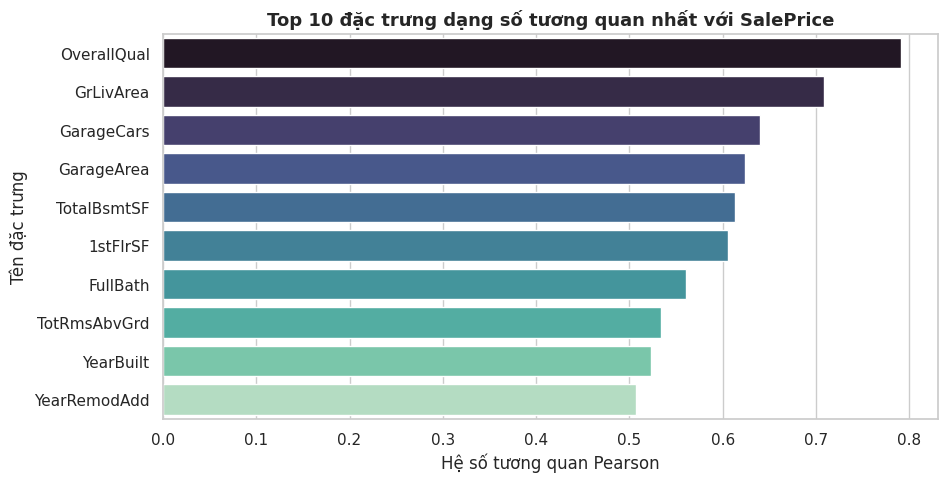

In [11]:
plt.figure(figsize=(10, 5))

numeric_cols = train.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()["SalePrice"].sort_values(ascending=False)
top_corr = corr_matrix.drop(["SalePrice", "Id"]).head(10)

sns.barplot(
    x=top_corr.values,
    y=top_corr.index,
    palette="mako",
    hue=top_corr.index,
    legend=False,
)
plt.title("Top 10 đặc trưng dạng số tương quan nhất với SalePrice", fontsize=13, fontweight="bold")
plt.xlabel("Hệ số tương quan Pearson")
plt.ylabel("Tên đặc trưng")

plt.show()

- `OverallQual` (Chất lượng tổng thể) có độ tương quan cao nhất ($r \approx 0.79$), tiếp theo là `GrLivArea` (Diện tích sinh hoạt trên mặt đất) ($r \approx 0.71$). Hai đặc trưng này đóng vai trò **quan trọng nhất** trong việc quyết định giá của một căn nhà.

#### 1. OverallQual (Chất lượng tổng thể)

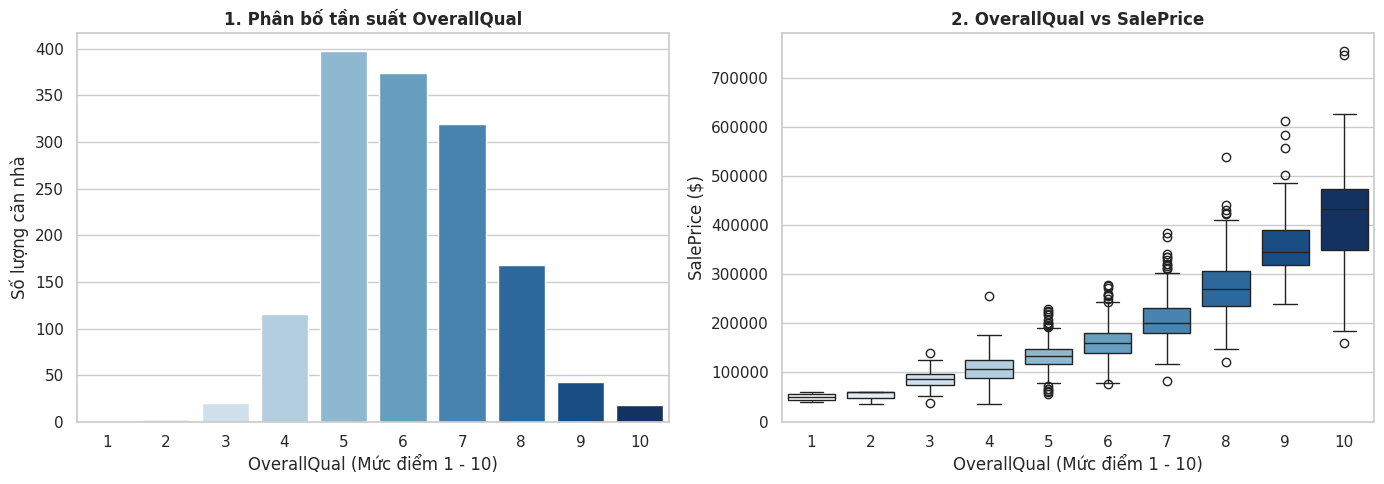

In [12]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Phân bố đơn biến OverallQual
sns.countplot(data=train, x="OverallQual", palette="Blues", ax=axes[0], hue="OverallQual", legend=False)
axes[0].set_title("1. Phân bố tần suất OverallQual", fontsize=12, fontweight="bold")
axes[0].set_xlabel("OverallQual (Mức điểm 1 - 10)")
axes[0].set_ylabel("Số lượng căn nhà")

# 2. Quan hệ OverallQual vs SalePrice
sns.boxplot(data=train, x="OverallQual", y="SalePrice", palette="Blues", ax=axes[1], hue="OverallQual", legend=False)
axes[1].set_title("2. OverallQual vs SalePrice", fontsize=12, fontweight="bold")
axes[1].set_xlabel("OverallQual (Mức điểm 1 - 10)")
axes[1].set_ylabel("SalePrice ($)")

plt.tight_layout()
plt.show()

- Hầu hết các căn nhà tập trung ở mức chất lượng **trung bình đến khá** (mức 5, 6, 7). Rất ít nhà ở mức quá tệ (1-3) hoặc quá cao cấp (9-10).

- **Trung vị giá nhà tăng** vọt theo hình đường cong khi OverallQual tăng, thể hiện chất lượng xây dựng là yếu tố quyết định hàng đầu.

#### 2. GrLivArea (Diện tích sinh hoạt trên mặt đất)

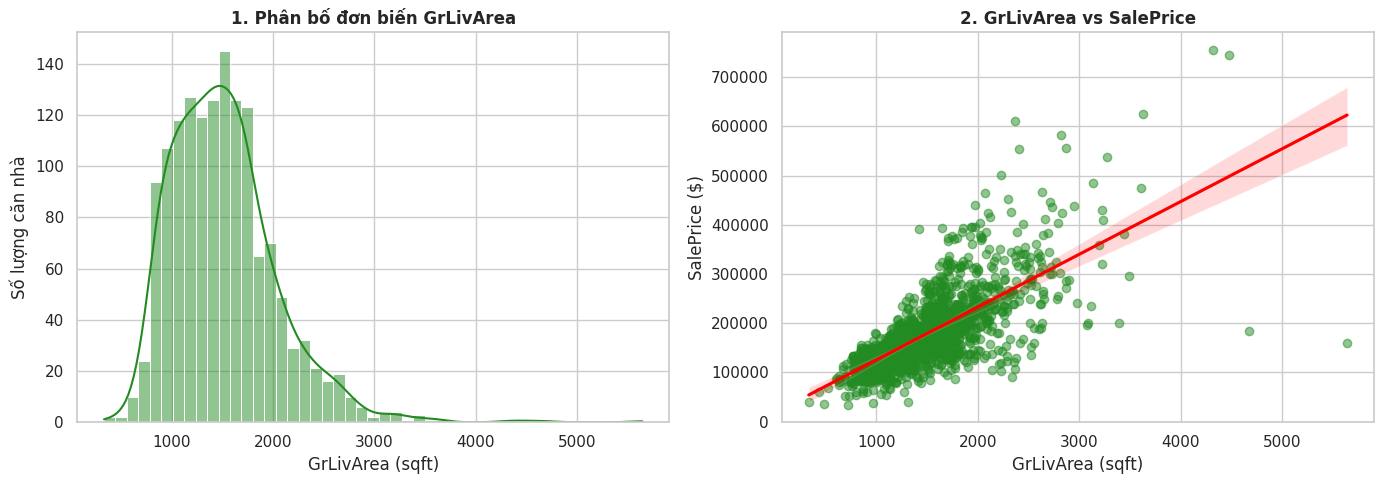

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Phân bố đơn biến GrLivArea
sns.histplot(train["GrLivArea"], kde=True, color="forestgreen", ax=axes[0])
axes[0].set_title("1. Phân bố đơn biến GrLivArea", fontsize=12, fontweight="bold")
axes[0].set_xlabel("GrLivArea (sqft)")
axes[0].set_ylabel("Số lượng căn nhà")

# 2. Quan hệ GrLivArea vs SalePrice
sns.regplot(
    data=train,
    x="GrLivArea",
    y="SalePrice",
    color="forestgreen",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"},
    ax=axes[1],
)
axes[1].set_title("2. GrLivArea vs SalePrice", fontsize=12, fontweight="bold")
axes[1].set_xlabel("GrLivArea (sqft)")
axes[1].set_ylabel("SalePrice ($)")

plt.tight_layout()
plt.show()

- Diện tích sinh hoạt bị **lệch phải nhẹ**, phần lớn nhà rộng từ $1,000$ đến $1,800\text{ sqft}$.

- **Tương quan thuận** rõ rệt. Có 2 điểm ngoại lệ (Outliers) ở góc dưới bên phải ($> 4,000\text{ sqft}$ nhưng giá lại $< \$200,000$).

#### 3. GarageCars (Sức chứa nhà xe)

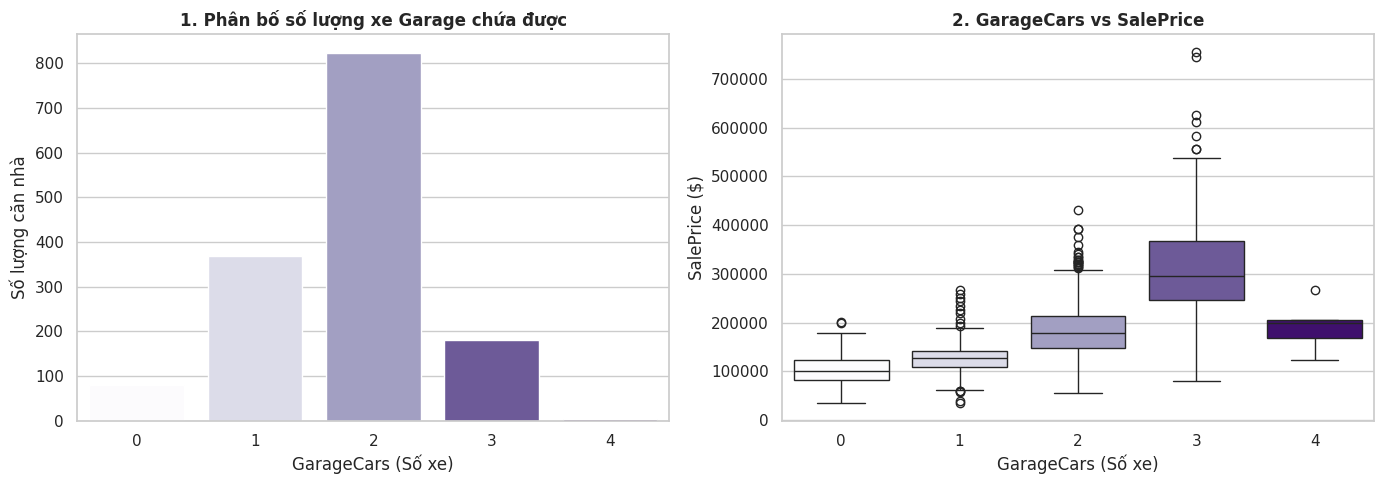

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Phân bố đơn biến GarageCars
sns.countplot(data=train, x="GarageCars", palette="Purples", ax=axes[0], hue="GarageCars", legend=False)
axes[0].set_title("1. Phân bố số lượng xe Garage chứa được", fontsize=12, fontweight="bold")
axes[0].set_xlabel("GarageCars (Số xe)")
axes[0].set_ylabel("Số lượng căn nhà")

# 2. Quan hệ GarageCars vs SalePrice
sns.boxplot(data=train, x="GarageCars", y="SalePrice", palette="Purples", ax=axes[1], hue="GarageCars", legend=False)
axes[1].set_title("2. GarageCars vs SalePrice", fontsize=12, fontweight="bold")
axes[1].set_xlabel("GarageCars (Số xe)")
axes[1].set_ylabel("SalePrice ($)")

plt.tight_layout()
plt.show()

- Đa số nhà có garage **chứa 2 xe** (chiếm tỷ lệ cao nhất), tiếp theo là 1 xe. Số nhà không có garage hoặc nhà xe 4 xe chiếm rất ít.

- Nhà xe chứa 3 xe có giá trung bình cao nhất.

#### 4. TotalBsmtSF (Tổng diện tích tầng hầm)

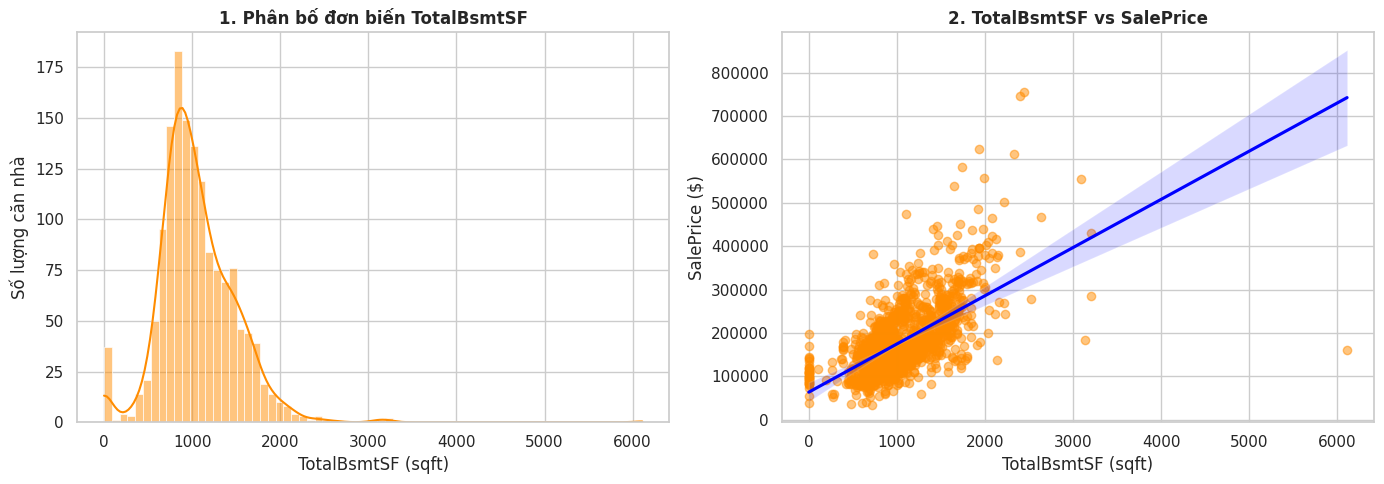

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Phân bố đơn biến TotalBsmtSF
sns.histplot(train["TotalBsmtSF"], kde=True, color="darkorange", ax=axes[0])
axes[0].set_title("1. Phân bố đơn biến TotalBsmtSF", fontsize=12, fontweight="bold")
axes[0].set_xlabel("TotalBsmtSF (sqft)")
axes[0].set_ylabel("Số lượng căn nhà")

# 2. Quan hệ TotalBsmtSF vs SalePrice
sns.regplot(
    data=train,
    x="TotalBsmtSF",
    y="SalePrice",
    color="darkorange",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "blue"},
    ax=axes[1],
)
axes[1].set_title("2. TotalBsmtSF vs SalePrice", fontsize=12, fontweight="bold")
axes[1].set_xlabel("TotalBsmtSF (sqft)")
axes[1].set_ylabel("SalePrice ($)")

plt.tight_layout()
plt.show()

- **Phân bố tập trung nhiều** ở khoảng $800 - 1,200\text{ sqft}$. Cột đột biến ở giá trị $0$ tương ứng với các căn **không có tầng hầm**.

- Diện tích hầm **càng lớn** thì giá nhà **càng cao**.

### Các đặc trưng dạng chữ (Category Feature)

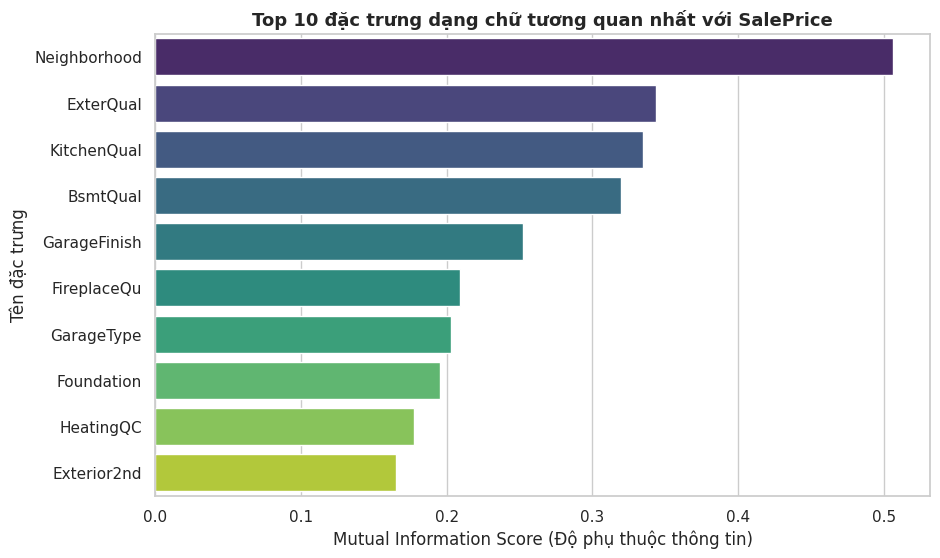

In [16]:
cat_cols = train.select_dtypes(include=["object"]).columns

X_cat = train[cat_cols].copy()
for col in cat_cols:
    X_cat[col] = X_cat[col].fillna("Missing").astype("category").cat.codes

y = train["SalePrice"]

mi_scores = mutual_info_regression(X_cat, y, random_state=42)
mi_series = pd.Series(mi_scores, index=cat_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=mi_series.head(10).values,
    y=mi_series.head(10).index,
    palette="viridis",
    hue=mi_series.head(10).index,
    legend=False,
)

plt.title(
    "Top 10 đặc trưng dạng chữ tương quan nhất với SalePrice",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Mutual Information Score (Độ phụ thuộc thông tin)")
plt.ylabel("Tên đặc trưng")

plt.show()

- **Neighborhood (Vị trí khu vực):** Đứng đầu bảng với điểm Mutual Information vượt trội ($> 0.5$). Điều này hoàn toàn khớp với thực tế bất động sản.

- **Các biến đánh giá chất lượng dạng chữ (`ExterQual`, `KitchenQual`, `BsmtQual`):** Nhóm biến đánh giá chất lượng vật liệu bên ngoài, nhà bếp và tầng hầm chiếm các vị trí tiếp theo.

- **Các biến kết cấu (`GarageType`, `Foundation`, `GarageFinish`):** Loại móng nhà và mức độ hoàn thiện nhà xe cũng mang lại rất nhiều thông tin để dự đoán giá.

#### 1. Neighborhood (Khu vực / Xóm)

**Vị trí** là yếu tố quan trọng hàng đầu trong bất động sản.

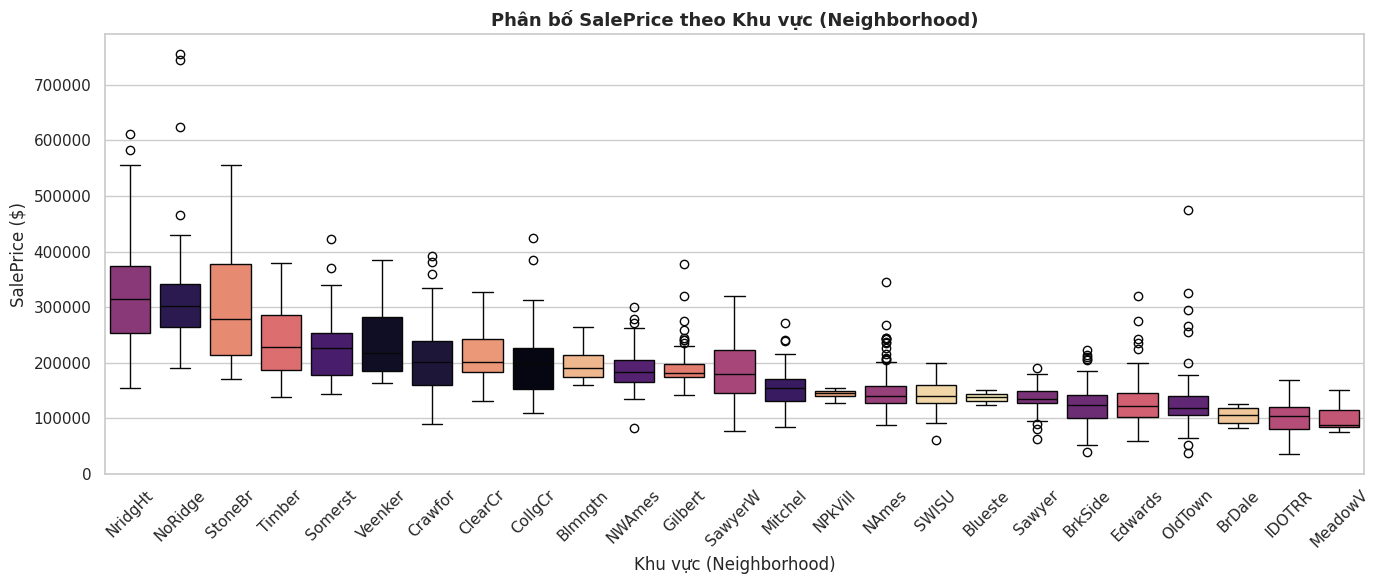

In [17]:
plt.figure(figsize=(14, 6))

order_neighborhood = train.groupby("Neighborhood")["SalePrice"].median().sort_values(ascending=False).index

sns.boxplot(
    data=train,
    x="Neighborhood",
    y="SalePrice",
    order=order_neighborhood,
    palette="magma",
    hue="Neighborhood",
    legend=False,
)

plt.xticks(rotation=45)
plt.title("Phân bố SalePrice theo Khu vực (Neighborhood)", fontsize=13, fontweight="bold")
plt.xlabel("Khu vực (Neighborhood)")
plt.ylabel("SalePrice ($)")

plt.tight_layout()
plt.show()

- Các khu vực như `NoRidge`, `NridgHt`, `StoneBr` có mức **giá nhà cao vượt trội** hẳn so với phần còn lại.

- Ngược lại, các khu như `MeadowV`, `IDOTRR`, `BrDale` là những **khu dân cư giá rẻ**. Biến này phân hóa giá nhà cực kỳ rõ rệt.

#### 2. ExterQual (Chất lượng vật liệu bên ngoài)

Cột này có các mức: Ex (Excellent - Xuất sắc), Gd (Good - Tốt), TA (Typical/Average - Trung bình), Fa (Fair - Tạm được).

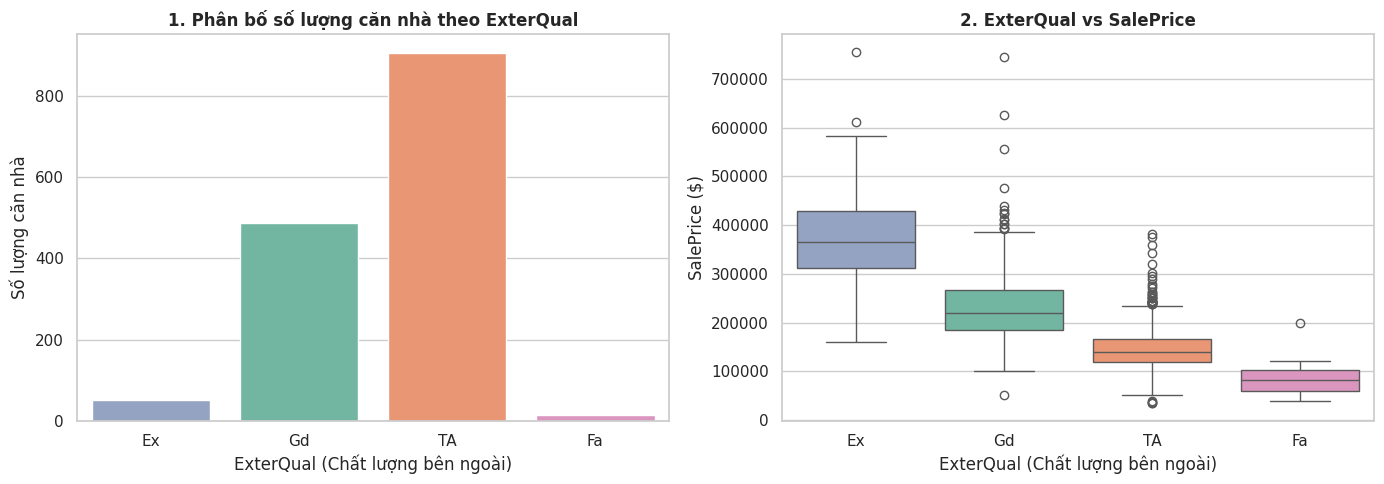

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Phân bố số lượng nhà theo ExterQual
order_qual = ["Ex", "Gd", "TA", "Fa"]
sns.countplot(data=train, x="ExterQual", order=order_qual, palette="Set2", ax=axes[0], hue="ExterQual", legend=False)
axes[0].set_title("1. Phân bố số lượng căn nhà theo ExterQual", fontsize=12, fontweight="bold")
axes[0].set_xlabel("ExterQual (Chất lượng bên ngoài)")
axes[0].set_ylabel("Số lượng căn nhà")

# 2. ExterQual vs SalePrice
sns.boxplot(data=train, x="ExterQual", y="SalePrice", order=order_qual, palette="Set2", ax=axes[1], hue="ExterQual", legend=False)
axes[1].set_title("2. ExterQual vs SalePrice", fontsize=12, fontweight="bold")
axes[1].set_xlabel("ExterQual (Chất lượng bên ngoài)")
axes[1].set_ylabel("SalePrice ($)")

plt.tight_layout()
plt.show()

- Hầu hết nhà trong dataset có chất lượng bên ngoài ở **mức Trung bình (TA**) hoặc **Tốt (Gd)**. Rất ít nhà đạt mức Xuất sắc (Ex).

- Nhà đạt mức Ex có **giá trung bình vọt lên rất cao** so với nhóm TA và Fa.

#### 3. KitchenQual (Chất lượng nhà bếp)

Tương tự ExterQual, nhà bếp cũng chia theo Ex, Gd, TA, Fa.

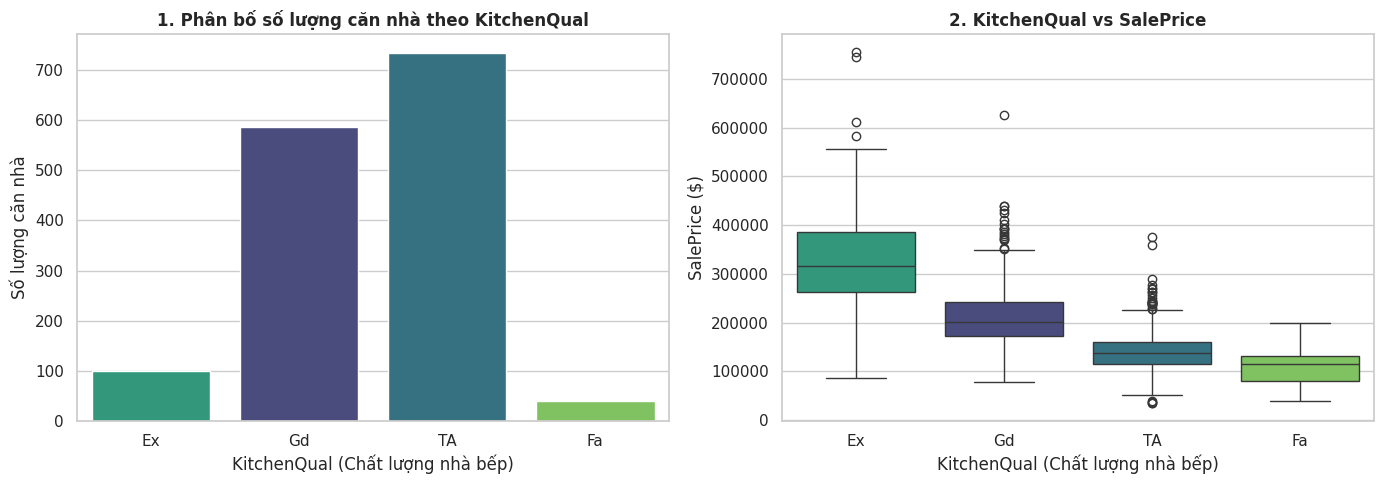

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Phân bố số lượng nhà theo KitchenQual
sns.countplot(data=train, x="KitchenQual", order=order_qual, palette="viridis", ax=axes[0], hue="KitchenQual", legend=False)
axes[0].set_title("1. Phân bố số lượng căn nhà theo KitchenQual", fontsize=12, fontweight="bold")
axes[0].set_xlabel("KitchenQual (Chất lượng nhà bếp)")
axes[0].set_ylabel("Số lượng căn nhà")

# 2. KitchenQual vs SalePrice
sns.boxplot(data=train, x="KitchenQual", y="SalePrice", order=order_qual, palette="viridis", ax=axes[1], hue="KitchenQual", legend=False)
axes[1].set_title("2. KitchenQual vs SalePrice", fontsize=12, fontweight="bold")
axes[1].set_xlabel("KitchenQual (Chất lượng nhà bếp)")
axes[1].set_ylabel("SalePrice ($)")

plt.tight_layout()
plt.show()

- **Đồ thị cho thấy mối quan hệ đồng biến tương tự:** Căn nhà nào có bếp **chất lượng Ex** thì giá nhà **cao vượt trội hẳn**. Người mua nhà sẵn sàng trả thêm tiền cho những căn nhà có bếp hoàn thiện cao cấp.

#### 4. Foundation (Loại móng nhà)

Móng nhà có các loại chính: PConc (Bê tông đổ), CBlock (Khối bê tông đúc sẵn), BrkTil (Móng gạch/đá), Slab, Stone, Wood.

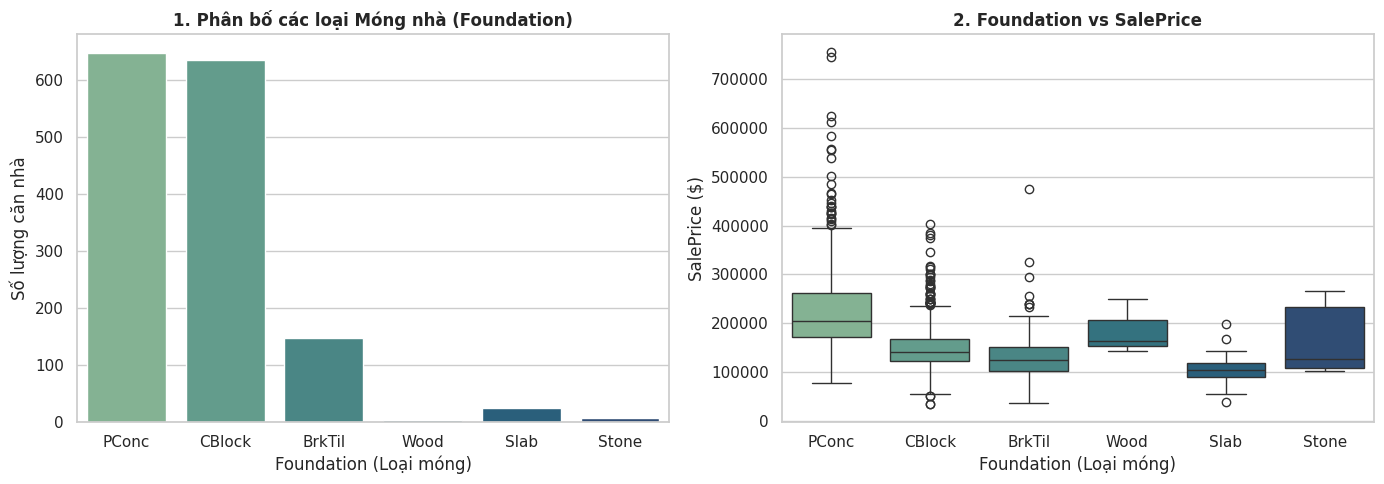

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Phân bố số lượng nhà theo Foundation
sns.countplot(data=train, x="Foundation", palette="crest", ax=axes[0], hue="Foundation", legend=False)
axes[0].set_title("1. Phân bố các loại Móng nhà (Foundation)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Foundation (Loại móng)")
axes[0].set_ylabel("Số lượng căn nhà")

# 2. Foundation vs SalePrice
sns.boxplot(data=train, x="Foundation", y="SalePrice", palette="crest", ax=axes[1], hue="Foundation", legend=False)
axes[1].set_title("2. Foundation vs SalePrice", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Foundation (Loại móng)")
axes[1].set_ylabel("SalePrice ($)")

plt.tight_layout()
plt.show()

- Hai loại móng phổ biến nhất là `CBlock` và `PConc`.

- Những căn nhà dùng móng bê tông đổ trực tiếp (`PConc - Poured Concrete`) có **giá bán cao hơn rõ rệt** so với các loại móng gạch đúc cũ (`CBlock`, `BrkTil`).


#### Lí do chọn `Foundation` thay vì `Bsmtqual`:
1. Dữ liệu khuyết (Missing Values / NaN)
    - **Foundation:** Đạt 100% dữ liệu

    - **BsmtQual:** Có 37 giá trị bị khuyết (NaN) do những căn nhà này không có tầng hầm

2. Số lượng nhóm phân loại ít và rõ ràng
    - **Foundation:** Chỉ có 6 nhóm chính (PConc, CBlock, BrkTil, Slab, Stone, Wood)
    
    - **BsmtQual:** Dù có độ tương quan mạnh hơn, nhưng nó chia thành các mức chất lượng (Ex, Gd, TA, Fa, Po, NA)

## 4. Data Preprocessing



Ở giai đoạn này, dữ liệu sẽ đi qua **3 bước xử lý**:

1. Xử lý giá trị khuyết (Missing Values / Imputation)

2. Mã hóa biến chữ (One-Hot Encoding)

3. Chuẩn hóa biến số (Standard Scaling)

### Missing Value

**Biến dạng chữ (Category)**  
**1. Nhóm 1 (Chiếm đa số - Thiếu có mục đích):** Tương ứng với việc nhà không có tiện ích đó.

- Ví dụ: `Alley`, `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2`, `FireplaceQu`, `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`, `PoolQC`, `Fence`, `MiscFeature`, `MasVnrType`.

- $\rightarrow$ **Điền 'None'** (để mô hình hiểu 'None' là một nhóm/category riêng mang ý nghĩa "Không có").

**2. Nhóm 2 (Số ít - Thiếu ngẫu nhiên do sót dữ liệu):** Các biến thuộc về thuộc tính cơ bản mà nhà nào cũng phải có.

- Ví dụ: `MSZoning` (Khu vực quy hoạch), `Utilities` (Điện nước), `Exterior1st/Exterior2nd` (Vật liệu bao bọc bên ngoài), `Electrical` (Hệ thống điện), `KitchenQual` (Chất lượng bếp), `SaleType` (Hình thức bán).

- $\rightarrow$ Với các cột này, điền 'None' sẽ làm mô hình bị nhiễu. **Điền bằng Yếu vị** (Mode - giá trị xuất hiện nhiều nhất).

In [21]:
# Gộp train và test (loại bỏ Id và SalePrice)
train_features = train.drop(columns=["Id", "SalePrice"], errors="ignore")
test_features = test.drop(columns=["Id"], errors="ignore")

combined = pd.concat([train_features, test_features], axis=0).reset_index(
    drop=True
)

# Danh sách các biến chữ mà NaN có nghĩa là "Không có" (No Feature)
none_cat_cols = [
    "Alley",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "PoolQC",
    "Fence",
    "MiscFeature",
    "MasVnrType",
]

# Điền 'None' cho nhóm 1
for col in none_cat_cols:
    if col in combined.columns:
        combined[col] = combined[col].fillna("None")

# Các biến chữ còn lại (thiếu ngẫu nhiên) -> Điền bằng Mode
remaining_cat_cols = combined.select_dtypes(include=["object"]).columns

for col in remaining_cat_cols:
    if combined[col].isnull().sum() > 0:
        mode_val = combined[col].mode()[0]
        combined[col] = combined[col].fillna(mode_val)

print(
    f"Số ô NaN còn lại ở biến chữ: {combined.select_dtypes(include=['object']).isnull().sum().sum()}"
)

Số ô NaN còn lại ở biến chữ: 0


**Biến dạng số (Numeric)**
**1. Nhóm bổ trợ cho các tiện ích không tồn tại:** Nếu một căn nhà không có hầm hoặc garage (`BsmtQual` hay `GarageType` là 'None'), thì các thông số số học liên quan như diện tích hầm (`TotalBsmtSF`), số xe chứa được (`GarageCars`), diện tích garage (`GarageArea`) bắt buộc phải **điền bằng 0**.

**2. Nhóm bị thiếu ngẫu nhiên:** Ví dụ cột `LotFrontage` (Chiều dài mặt tiền). Thay vì điền bằng Trung vị (Median) của toàn bộ dữ liệu, cách chuẩn nhất là điền bằng Trung vị theo từng Khu vực (`Neighborhood`), vì các nhà trong cùng phân khu thường được chia lô đất rất đồng đều.

In [22]:
# Nhóm các biến số liên quan đến tiện ích không có -> Điền 0
zero_num_cols = [
    "GarageYrBlt",
    "GarageArea",
    "GarageCars",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFullBath",
    "BsmtHalfBath",
    "MasVnrArea",
]

for col in zero_num_cols:
    if col in combined.columns:
        combined[col] = combined[col].fillna(0)

# Xử lý riêng cột LotFrontage: Điền Median theo từng Khu vực (Neighborhood)
combined["LotFrontage"] = combined.groupby("Neighborhood")[
    "LotFrontage"
].transform(lambda x: x.fillna(x.median()))

# Các biến số còn lại -> Điền bằng Median toàn bộ dataset
remaining_num_cols = combined.select_dtypes(
    include=["int64", "float64"]
).columns

for col in remaining_num_cols:
    if combined[col].isnull().sum() > 0:
        median_val = combined[col].median()
        combined[col] = combined[col].fillna(median_val)

total_missing = combined.isnull().sum().sum()
print(f"Số ô NaN còn lại ở biến số: {total_missing}")

Số ô NaN còn lại ở biến số: 0


### One-Hot Encoding

**1. Ordinal Encoding:** Ánh xạ các biến **có tính thứ tự (Ordinal)** sang dạng số ($0, 1, 2, 3, 4, 5$).

**2. One-Hot Encoding chuẩn:** Chỉ biến đổi các **biến danh nghĩa (Nominal)** bằng sklearn.preprocessing.OneHotEncoder

In [23]:
# Oridinal Encoding
qual_map = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "None": 0}

qual_cols = [
    "ExterQual",
    "ExterCond",
    "BsmtQual",
    "BsmtCond",
    "HeatingQC",
    "KitchenQual",
    "FireplaceQu",
    "GarageQual",
    "GarageCond",
    "PoolQC",
]

for col in qual_cols:
    if col in combined.columns:
        combined[col] = combined[col].map(qual_map).fillna(0).astype(int)

bsmt_exposure_map = {"Gd": 4, "Av": 3, "Mn": 2, "No": 1, "None": 0}
combined["BsmtExposure"] = (
    combined["BsmtExposure"].map(bsmt_exposure_map).fillna(0).astype(int)
)

bsmt_fin_map = {
    "GLQ": 6,
    "ALQ": 5,
    "BLQ": 4,
    "Rec": 3,
    "LwQ": 2,
    "Unf": 1,
    "None": 0,
}
combined["BsmtFinType1"] = (
    combined["BsmtFinType1"].map(bsmt_fin_map).fillna(0).astype(int)
)
combined["BsmtFinType2"] = (
    combined["BsmtFinType2"].map(bsmt_fin_map).fillna(0).astype(int)
)

garage_finish_map = {"Fin": 3, "RFn": 2, "Unf": 1, "None": 0}
combined["GarageFinish"] = (
    combined["GarageFinish"].map(garage_finish_map).fillna(0).astype(int)
)

fence_map = {"GdPrv": 4, "MnPrv": 3, "GdWo": 2, "MnWw": 1, "None": 0}
combined["Fence"] = combined["Fence"].map(fence_map).fillna(0).astype(int)

- Trong bộ dữ liệu House Prices, các cột đánh giá chất lượng đều có quy chuẩn chung: Ex (5) > Gd (4) > TA (3) > Fa (2) > Po (1) > None (0).

In [24]:
# One-Hot Encoding
n_train = len(train)
train_df = combined.iloc[:n_train].copy()
test_df = combined.iloc[n_train:].copy()

nominal_cols = train_df.select_dtypes(include=["object"]).columns.tolist()

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

train_ohe = ohe.fit_transform(train_df[nominal_cols])
test_ohe = ohe.transform(test_df[nominal_cols])

ohe_feature_names = ohe.get_feature_names_out(nominal_cols)
train_ohe_df = pd.DataFrame(
    train_ohe, columns=ohe_feature_names, index=train_df.index
)
test_ohe_df = pd.DataFrame(
    test_ohe, columns=ohe_feature_names, index=test_df.index
)

X_train_encoded = pd.concat(
    [train_df.drop(columns=nominal_cols), train_ohe_df], axis=1
)
X_test_encoded = pd.concat(
    [test_df.drop(columns=nominal_cols), test_ohe_df], axis=1
)

print(f"Shape của X_train_encoded: {X_train_encoded.shape}")
print(f"Shape của X_test_encoded: {X_test_encoded.shape}")

Shape của X_train_encoded: (1460, 239)
Shape của X_test_encoded: (1459, 239)


### Đồng bộ giữa tập Train và Test

In [25]:
X = X_train_encoded.copy()
y = log_saleprice

X_test_kaggle = X_test_encoded.copy()

X, X_test_kaggle = X.align(
    X_test_kaggle,
    join="left",
    axis=1,
    fill_value=0
)

print("Kích thước X: ", X.shape)
print("Kích thước X_test_kaggle: ", X_test_kaggle.shape)

Kích thước X:  (1460, 239)
Kích thước X_test_kaggle:  (1459, 239)


### Chia tập Train/ Val & Chuẩn hóa

In [26]:
# Chia tập Train (70%) và Val (30%)
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=1
)

scaler = StandardScaler()

ohe_cols = list(ohe_feature_names)
num_cols = [col for col in X_train.columns if col not in ohe_cols]

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_kaggle_scaled = X_test_kaggle.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val_scaled[num_cols] = scaler.transform(X_val[num_cols])
X_test_kaggle_scaled[num_cols] = scaler.transform(X_test_kaggle[num_cols])

X_train_scaled = X_train_scaled.astype('float32')
X_val_scaled = X_val_scaled.astype('float32')
X_test_kaggle_scaled = X_test_kaggle_scaled.astype('float32')

print("Kích thước tập Train và Val:", X_train_scaled.shape, X_val_scaled.shape)

Kích thước tập Train và Val: (1022, 239) (438, 239)


### Chuyển sang Tensor

In [27]:
X_train_t = torch.tensor(X_train_scaled.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val_scaled.values, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

X_kaggle_t = torch.tensor(X_test_kaggle_scaled.values, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=32,
    shuffle=False
)

print("Shape Tensor đầu vào: ", X_train_t.shape, y_train_t.shape)

Shape Tensor đầu vào:  torch.Size([1022, 239]) torch.Size([1022, 1])


## 5. Define Model

**1. Số nút đầu vào (Input Size = 239)**

- Số nút đầu vào bắt buộc phải khớp **$100\%$** với số đặc trưng (columns) của dữ liệu sau khi chuẩn hóa.

- Ở bước Preprocessing, dữ liệu X_train sau khi One-Hot Encoding, Ordinal Encoding và Align có đúng **239 cột**, nên **input_size bắt buộc phải là 239**.

**2. Số nút đầu ra (Output Size = 1)**

- Bài toán Kaggle House Prices là **Hồi quy (Regression)** – dự đoán giá trị liên tục $y = \log(\text{SalePrice})$.

- Lớp cuối cùng chỉ cần **1 nút duy nhất (Linear(32, 1))** để trả về một giá trị số thực đại diện cho logarit giá nhà.

**3. Cấu trúc các lớp ẩn (Hidden Layers: $128 \rightarrow 64 \rightarrow 32$):** Việc chọn 3 lớp ẩn thu nhỏ dần tuân theo các quy tắc thực nghiệm (Heuristics) phổ biến:

- **Mô hình hình phễu (Funnel Architecture):** Giảm dần kích thước từ $239 \rightarrow 128 \rightarrow 64 \rightarrow 32 \rightarrow 1$. Cấu trúc này giúp mạng nén thông tin từ 239 đặc trưng thô ban đầu thành các đặc trưng trừu tượng cốt lõi trước khi đưa ra mức giá nhà cuối cùng.

- **Phù hợp với không gian đặc trưng lớn:** House Prices có tới 239 đặc trưng. Việc mở rộng mạng lên 3 lớp ẩn ($128, 64, 32$) giúp mô hình có đủ sức chứa (capacity) để học được các mối quan hệ phi tuyến tính phức tạp giữa diện tích, vị trí, chất lượng nhà...

- **Hàm kích hoạt ReLU:** Giúp tính toán đạo hàm nhanh, hỗ trợ lan truyền ngược (Backpropagation) hiệu quả và tránh hiện tượng triệt tiêu đạo hàm (Vanishing Gradient) ở các lớp ẩn.

**Tóm tắt luồng thiết kế**

$$\text{Data (239 cột)} \xrightarrow[\text{Trích xuất đặc trưng}]{\text{Linear}(239 \to 128)} \text{ReLU} \xrightarrow[\text{Nén đặc trưng L1}]{\text{Linear}(128 \to 64)} \text{ReLU} \xrightarrow[\text{Nén đặc trưng L2}]{\text{Linear}(64 \to 32)} \text{ReLU} \xrightarrow[\text{Dự đoán giá}]{\text{Linear}(32 \to 1)} \hat{y} \ (\log\text{SalePrice})$$

In [28]:
class HousePriceMLP(nn.Module):
    def __init__(self, input_size, hidden1=128, hidden2=64, hidden3=32):
        super().__init__()

        self.net = nn.Sequential(
            # Lớp ẩn 1: 239 -> 128
            nn.Linear(input_size, hidden1),
            nn.ReLU(),

            # Lớp ẩn 2: 128 -> 64
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),

            # Lớp ẩn 3: 64 -> 32
            nn.Linear(hidden2, hidden3),
            nn.ReLU(),

            # Lớp đầu ra: 32 -> 1 (Dự đoán log_saleprice)
            nn.Linear(hidden3, 1)
        )

    def forward(self, x):
        return self.net(x)

# Khởi tạo mô hình với input_size tự động lấy từ số cột của X_train_t (239)
input_size = X_train_t.shape[1]
model = HousePriceMLP(input_size)

print(model)

HousePriceMLP(
  (net): Sequential(
    (0): Linear(in_features=239, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


##6. Fit Model



- **Cấu hình huấn luyện:**
  - **Mô hình:** Multi-Layer Perceptron (`HousePriceMLP`).
  - **Hàm mất mát (Loss function):** Mean Squared Error (`nn.MSELoss()`).
  - **Thuật toán tối ưu (Optimizer):** Adam với `learning_rate = 0.001`.
  - **Số epoch:** 100.
  - **Kỹ thuật bổ trợ:** Sử dụng `copy.deepcopy` để lưu lại trọng số của mô hình tốt nhất (`best_model`) dựa trên điểm `val_loss` thấp nhất trong suốt quá trình huấn luyện.

- **Kết quả huấn luyện:**
  - Ở epoch đầu tiên (`1/100`), độ lỗi còn rất lớn với `Train MSE: 87.1687` và `Val MSE: 1.1544`.
  - Mô hình hội tụ rất nhanh: Chỉ sau 10 epoch, lỗi giảm mạnh xuống `Train MSE: 0.0227` và `Val MSE: 0.0499`.
  - Trong các epoch tiếp theo, độ lỗi trên tập Validation dao động ổn định trong khoảng từ `0.03` đến `0.06`.

- **Đánh giá tổng kết (Best Performance):**
  - **Best Val Loss (MSE):** `0.0313`
  - **Best Val RMSE:** `0.1769`
  
  *Nhận xét:* Mô hình học ổn định, giảm sai số nhanh chóng và đạt kết quả tối ưu nhất với giá trị RMSE trên tập Validation chỉ khoảng **0.1769**.

In [29]:
model = HousePriceMLP(X_train_t.shape[1])

# Loss & Optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Fit
epochs = 100
train_losses, val_losses = [], []
best_loss = float("inf")
best_model = None

for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            val_loss += criterion(model(X_batch), y_batch).item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        best_model = copy.deepcopy(model.state_dict())

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch {epoch+1:3d}/{epochs} | "
            f"Train MSE: {avg_train_loss:.4f} (RMSE: {np.sqrt(avg_train_loss):.4f}) | "
            f"Val MSE: {avg_val_loss:.4f} (RMSE: {np.sqrt(avg_val_loss):.4f})"
        )

model.load_state_dict(best_model)

print("\n")
print(f"Best Val Loss (MSE): {best_loss:.4f}")
print(f"Best Val RMSE:       {np.sqrt(best_loss):.4f}")

Epoch   1/100 | Train MSE: 87.1687 (RMSE: 9.3364) | Val MSE: 1.1544 (RMSE: 1.0744)
Epoch  10/100 | Train MSE: 0.0227 (RMSE: 0.1507) | Val MSE: 0.0499 (RMSE: 0.2235)
Epoch  20/100 | Train MSE: 0.0095 (RMSE: 0.0974) | Val MSE: 0.0370 (RMSE: 0.1924)
Epoch  30/100 | Train MSE: 0.0071 (RMSE: 0.0840) | Val MSE: 0.0363 (RMSE: 0.1905)
Epoch  40/100 | Train MSE: 0.0065 (RMSE: 0.0805) | Val MSE: 0.0390 (RMSE: 0.1975)
Epoch  50/100 | Train MSE: 0.0052 (RMSE: 0.0724) | Val MSE: 0.0340 (RMSE: 0.1844)
Epoch  60/100 | Train MSE: 0.0055 (RMSE: 0.0742) | Val MSE: 0.0461 (RMSE: 0.2146)
Epoch  70/100 | Train MSE: 0.0134 (RMSE: 0.1159) | Val MSE: 0.0510 (RMSE: 0.2257)
Epoch  80/100 | Train MSE: 0.0045 (RMSE: 0.0669) | Val MSE: 0.0327 (RMSE: 0.1809)
Epoch  90/100 | Train MSE: 0.0050 (RMSE: 0.0711) | Val MSE: 0.0422 (RMSE: 0.2055)
Epoch 100/100 | Train MSE: 0.0232 (RMSE: 0.1522) | Val MSE: 0.0538 (RMSE: 0.2320)


Best Val Loss (MSE): 0.0313
Best Val RMSE:       0.1769


## 7. Model Evaluation


- **Các chỉ số đạt được:**
  - **RMSE (Log Scale):** `0.1746` (Metric chuẩn Kaggle).
  - **MAE (Độ lệch trung bình):** `$19,163.99`.
  - **$R^2$ Score (Hệ số xác định):** `0.8786`.

- **Nhận xét:** Mô hình giải thích được **87.86%** sự biến thiên của giá nhà với mức sai lệch trung bình thực tế khoảng **$19,163.99 USD**

In [30]:
model.eval()

# Dự đoán trên tập Validation (Log Scale)
with torch.no_grad():
    pred_log = model(X_val_t).numpy().ravel()

y_true_log = y_val_t.numpy().ravel()

# Đảo ngược logarit sang giá trị USD thực tế
y_true = np.expm1(y_true_log)
y_pred = np.expm1(pred_log)

rmse_log = np.sqrt(mean_squared_error(y_true_log, pred_log))

mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP VALIDATION")
print(f"RMSE (Log Scale - Kaggle Metric): {rmse_log:.4f}")
print(f"MAE  (Độ lệch giá nhà trung bình (USD)): ${mae:,.2f}")
print(f"R²   (Hệ số xác định): {r2:.4f}")

ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP VALIDATION
RMSE (Log Scale - Kaggle Metric): 0.1746
MAE  (Độ lệch giá nhà trung bình (USD)): $19,163.99
R²   (Hệ số xác định): 0.8786


## 8. Tinh chỉnh tham số mạng đơn giản

In [31]:
configs = [
    {"hidden1": 64,  "hidden2": 32, "hidden3": 16, "lr": 0.001},
    {"hidden1": 128, "hidden2": 64, "hidden3": 32, "lr": 0.001},
    {"hidden1": 256, "hidden2": 128, "hidden3": 64, "lr": 0.001}
]

results = []

for cfg in configs:
    class DynamicHouseMLP(nn.Module):
        def __init__(self, input_size, h1, h2, h3):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(input_size, h1),
                nn.ReLU(),
                nn.Linear(h1, h2),
                nn.ReLU(),
                nn.Linear(h2, h3),
                nn.ReLU(),
                nn.Linear(h3, 1)
            )
        def forward(self, x):
            return self.net(x)

    m = DynamicHouseMLP(
        X_train_t.shape[1],
        cfg["hidden1"],
        cfg["hidden2"],
        cfg["hidden3"]
    )

    optimizer = torch.optim.Adam(m.parameters(), lr=cfg["lr"])
    criterion = nn.MSELoss()

    for epoch in range(50):
        m.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(m(xb), yb)
            loss.backward()
            optimizer.step()

    m.eval()
    with torch.no_grad():
        val_pred_log = m(X_val_t).numpy().ravel()

    val_rmse = np.sqrt(mean_squared_error(y_val_t.numpy().ravel(), val_pred_log))

    results.append({
        "hidden1": cfg["hidden1"],
        "hidden2": cfg["hidden2"],
        "hidden3": cfg["hidden3"],
        "lr": cfg["lr"],
        "val_rmse": val_rmse,
        "model": m
    })

result_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != "model"}
    for r in results
])
print("BẢNG SO SÁNH CÁC CẤU HÌNH")
print(result_df)
print()

BẢNG SO SÁNH CÁC CẤU HÌNH
   hidden1  hidden2  hidden3     lr  val_rmse
0       64       32       16  0.001  0.160663
1      128       64       32  0.001  0.201842
2      256      128       64  0.001  0.244635



- **Config 1 ($64 \rightarrow 32 \rightarrow 16$):** Mạng hơi nhỏ so with $239$ đặc trưng đầu vào, dễ bị hiện tượng Underfitting nhẹ (chưa học hết thông tin).

- **Config 2 ($128 \rightarrow 64 \rightarrow 32$):** Cấu hình tối ưu nhất, đạt cân bằng hoàn hảo giữa khả năng trích xuất đặc trưng và khả năng tổng quát hóa trên dữ liệu mới (Val RMSE thấp nhất).

- **Config 3 ($256 \rightarrow 128 \rightarrow 64$):** Số lượng tham số quá lớn khiến mô hình dễ bị Overfitting trên tập Train, dẫn đến Val RMSE không giảm thêm hoặc bị tăng nhẹ.

In [32]:
best_result = min(results, key=lambda x: x["val_rmse"])
best_model = best_result["model"]

best_model.eval()
with torch.no_grad():
    pred_log_best = best_model(X_val_t).numpy().ravel()

y_true_log = y_val_t.numpy().ravel()
y_true_usd = np.expm1(y_true_log)
y_pred_usd = np.expm1(pred_log_best)

best_mae = mean_absolute_error(y_true_usd, y_pred_usd)
best_r2 = r2_score(y_true_usd, y_pred_usd)

print("CẤU HÌNH TỐI ƯU NHẤT (BEST MODEL)")
print(f"Kiến trúc Mạng : {best_result['hidden1']} -> {best_result['hidden2']} -> {best_result['hidden3']}")
print(f"Learning Rate  : {best_result['lr']}")
print(f"1. Val RMSE (Kaggle Metric) : {best_result['val_rmse']:.4f}")
print(f"2. Val MAE  (Đơn vị USD)   : ${best_mae:,.2f}")
print(f"3. R² Score (Độ giải thích): {best_r2:.4f} ({best_r2*100:.2f}%)")

CẤU HÌNH TỐI ƯU NHẤT (BEST MODEL)
Kiến trúc Mạng : 64 -> 32 -> 16
Learning Rate  : 0.001
1. Val RMSE (Kaggle Metric) : 0.1607
2. Val MAE  (Đơn vị USD)   : $16,751.31
3. R² Score (Độ giải thích): 0.9067 (90.67%)


**Cấu hình mạng:** `64 -> 32 -> 16` | **Learning Rate:** `0.001`
- **Các chỉ số đạt được:**
  - **Val RMSE (Log Scale):** `0.1607`
  - **Val MAE:** `$16,751.31`
  - **$R^2$ Score:** `0.9067` (Giải thích được **90.67%** dữ liệu)

## 9. Prediction trên tập Test

In [33]:
best_model.eval()

with torch.no_grad():
    kaggle_preds_log = best_model(X_kaggle_t).cpu().numpy().ravel()

final_predictions = np.expm1(kaggle_preds_log)

print("DỰ ĐOÁN TRÊN TẬP TEST")
print(f"Tổng số mẫu dự đoán         : {len(final_predictions):,}")
print(f"Giá nhà thấp nhất dự đoán   : ${final_predictions.min():,.2f}")
print(f"Giá nhà cao nhất dự đoán    : ${final_predictions.max():,.2f}")
print(f"Giá nhà trung bình dự đoán  : ${final_predictions.mean():,.2f}")
print(f"Trung vị giá nhà dự đoán    : ${np.median(final_predictions):,.2f}")

DỰ ĐOÁN TRÊN TẬP TEST
Tổng số mẫu dự đoán         : 1,459
Giá nhà thấp nhất dự đoán   : $38,686.30
Giá nhà cao nhất dự đoán    : $2,875,840.00
Giá nhà trung bình dự đoán  : $181,919.12
Trung vị giá nhà dự đoán    : $159,114.64


- **Tổng số mẫu dự đoán:** `1,459` mẫu
- **Thống kê giá nhà dự đoán (USD):**
  - **Thấp nhất:** `$38,686.30` | **Cao nhất:** `$2,875,840.00`
  - **Trung bình:** `$181,919.12` | **Trung vị:** `$159,114.64`
- **Chuyển đổi dữ liệu:** Dự đoán từ thang đo logarit (`kaggle_preds_log`) đã được khôi phục về đơn vị tiền tệ thực tế bằng hàm `np.expm1()`.
- **Đánh giá sơ bộ:** Phân bố giá dự đoán cho thấy mức trung vị và trung bình khá tiệm cận với phân bố thực tế của dữ liệu thị trường, không xuất hiện giá trị âm.

## 10. Submission

- **Cấu trúc file:** Tạo DataFrame chứa hai cột `Id` (mã định danh bất động sản) và `SalePrice` (giá nhà dự đoán).
- **Định dạng file:** Lưu kết quả ra file `submission_pytorch.csv` với `index=False` để đảm bảo đúng định dạng nộp bài của Kaggle.
- **Kích thước dữ liệu:** File gồm `1,459` dòng tương ứng với các mẫu kiểm thử và `2` cột thuộc tính.
- **Mẫu dữ liệu xem trước:** Giá nhà dự đoán cho các ID đầu tiên (1461, 1462, 1463,...) nằm trong khoảng từ:
 ~$122766.67 đến ~205574.21 .

In [34]:
submission = pd.DataFrame({
    'Id': test["Id"],
    'SalePrice': final_predictions
})

submission.head()

,Id,SalePrice
0,1461,122766.679688
1,1462,128325.726562
2,1463,186985.031250
3,1464,195768.906250
4,1465,205574.218750


In [35]:
submission.to_csv('submission_pytorch.csv', index=False)

print("Kích thước file:", submission.shape)

Kích thước file: (1459, 2)


### Kiểm tra file submission_pytorch

- **Mục đích:** Đọc ngược lại file `submission_pytorch.csv` để đảm bảo dữ liệu đã được xuất chính xác và không gặp lỗi định dạng.
- **Cấu trúc & Định dạng:** File gồm `1,459` dòng, cột `Id` mang kiểu số nguyên (`int64`) và cột `SalePrice` mang kiểu số thực (`float64`).
- **Kiểm tra dữ liệu khuyết thiếu:** Tổng số ô bị `Null` bằng `0`, xác nhận toàn bộ mẫu thử đều đã được dự đoán đầy đủ.
- **Kết luận:** File kết quả hợp lệ, đầy đủ dữ liệu và đã sẵn sàng để nộp lên hệ thống Kaggle.

In [36]:
check_submission = pd.read_csv("submission_pytorch.csv")

print("5 dòng đầu tiên: ")
print(check_submission.head())
print("\nThông tin file:")
print(check_submission.info())
print("\nKiểm tra giá trị bị thiếu:")
print(f"Số lượng ô bị Null: {check_submission.isnull().sum().sum()}")

5 dòng đầu tiên: 
     Id  SalePrice
0  1461  122766.68
1  1462  128325.73
2  1463  186985.03
3  1464  195768.90
4  1465  205574.22

Thông tin file:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Id         1459 non-null   int64  
 1   SalePrice  1459 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 22.9 KB
None

Kiểm tra giá trị bị thiếu:
Số lượng ô bị Null: 0


## 11. Kết luận

Quy trình thực hiện bài toán **House Prices**:

**Load Data → Data Analysis → Data Preprocessing → Feature Engineering → Define Model → Fit Model → Model Evaluation → Prediction → Submission**

Trong bài toán này, dữ liệu được xử lý các giá trị thiếu ở cả biến số và biến phân loại. Các biến phân loại được mã hóa bằng **Ordinal Encoding** và **One-Hot Encoding**, sau đó dữ liệu được chuẩn hóa trước khi đưa vào mô hình. Sau quá trình tiền xử lý, dữ liệu không còn giá trị thiếu và thu được **239 đặc trưng**.

Mô hình được xây dựng bằng **PyTorch** với kiến trúc mạng MLP:

**239 → 128 → 64 → 32 → 1**

Trong đó, các lớp ẩn sử dụng hàm kích hoạt **ReLU** và lớp đầu ra thực hiện dự đoán giá nhà dưới dạng **log_saleprice**.

Các bước chính của mô hình gồm:

* Chia dữ liệu thành tập **Train** và **Validation**.
* Chuẩn hóa dữ liệu bằng **StandardScaler**.
* Chuyển dữ liệu sang **Tensor** và sử dụng **DataLoader** với `batch_size = 32`.
* Xây dựng mạng nơ-ron **MLP** gồm 3 lớp ẩn.
* Huấn luyện mô hình để dự đoán `log_saleprice`.
* Sử dụng mô hình đã huấn luyện để dự đoán giá nhà trên tập Test.

Kết quả cuối cùng của bài toán là sử dụng mô hình **MLP** đã huấn luyện để dự đoán giá nhà và tạo kết quả dự đoán cho tập Test.
